<a href="https://colab.research.google.com/github/jomana199954-afk/GlucoSense---Al-Based-Diabetes-Prediction-System/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GlucoSense – AI-Based Diabetes Prediction System**

Project Description:
GlucoSense is an AI-based system designed to predict the risk of diabetes using machine learning techniques. The system analyzes medical data and provides an early warning to help prevent complications.

Objectives:
- Predict the likelihood of diabetes using patient data  
- Enable early detection of high-risk individuals  
- Provide an intelligent alert system  
- Compare machine learning models for best performance

Dataset:
The dataset used in this project is the Pima Indians Diabetes Dataset from Kaggle.

Features:
- Pregnancies  
- Glucose  
- Blood Pressure  
- Skin Thickness  
- Insulin  
- BMI  
- Diabetes Pedigree Function  
- Age

Target:
- Outcome (0 = No Diabetes, 1 = Diabetes)

Technologies Used
- Python  
- Scikit-learn  
- Pandas & NumPy  
- Machine Learning Models:
  - Logistic Regression  
  - Random Forest

Machine Learning Models

### 1. Logistic Regression
A simple and effective algorithm used for binary classification problems.

### 2. Random Forest
An ensemble learning method that improves accuracy by combining multiple decision trees.

Methodology

### 1. Data Collection
- Dataset loaded from CSV file

### 2. Data Preprocessing
- Handling missing values  
- Replacing invalid zeros  
- Feature scaling using StandardScaler  

### 3. Data Splitting
- 80% Training  
- 20% Testing  

### 4. Model Training
- Logistic Regression  
- Random Forest  

### 5. Model Evaluation
- Accuracy Score  
- Confusion Matrix  
- Classification Report  

### 6. Prediction System
- Input new patient data  
- Output risk probability  
- Generate alert if risk is high

GlucoSense Alert System
- High Risk → Probability > 70%  
- Medium Risk → 40% – 70%  
- Low Risk → < 40%  

##  Results
- Random Forest achieved higher accuracy compared to Logistic Regression  
- The system successfully predicts diabetes risk





In [ ]:
# ==============================
# 📌 GlucoSense Full Project
# AI-Based Diabetes Prediction System
# ==============================

# 📌 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 📌 2. Load Dataset
data = pd.read_csv('diabetes.csv')

print("Dataset Loaded Successfully ✅")
print(data.head())

# 📌 3. Data Cleaning
# Replace invalid zero values with mean
cols = ['Glucose', 'BloodPressure', 'BMI']

for col in cols:
    data[col] = data[col].replace(0, data[col].mean())

# 📌 4. Split Features & Target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 📌 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 📌 6. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 📌 7. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel Trained Successfully ✅")

# 📌 8. Model Evaluation
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\n📊 Model Accuracy:", round(accuracy * 100, 2), "%")

# ==============================
# 📌 9. GlucoSense Prediction System
# ==============================

def glucosense_predict(data_input):
    data_input = np.array(data_input).reshape(1, -1)
    data_input = scaler.transform(data_input)

    probability = model.predict_proba(data_input)[0][1]

    print("\n🔍 GlucoSense Result")
    print("Risk Probability:", round(probability * 100, 2), "%")

    if probability > 0.7:
        print("🚨 HIGH RISK: Immediate medical attention recommended!")
    elif probability > 0.4:
        print("⚠️ MEDIUM RISK: Monitor your health")
    else:
        print("✅ LOW RISK: You're safe")

# ==============================
# 📌 10. Test Example
# ==============================

sample_data = [2, 140, 80, 25, 100, 32.5, 0.5, 45]
glucosense_predict(sample_data)

# ==============================
# 📌 11. Feature Importance (Extra Strong Part)
# ==============================

print("\n📊 Feature Importance:")

importances = model.feature_importances_

for i, col in enumerate(X.columns):
    print(col, ":", round(importances[i], 3))

Dataset Loaded Successfully ✅
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Model Trained Successfully ✅

📊 Model Accuracy: 76.62 %

🔍 GlucoSense Result
Risk Probability: 72.0 %
🚨 HIGH RISK: Immediate medical attention recommended!

📊 Feature Importance:
Pregnancies : 0.077
Glucose : 0.27
BloodPressure : 0.091
SkinThickness : 0.065
Insulin : 0.07

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/tmp/ipykernel_64619/3397812260.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=data_plot, palette='viridis')


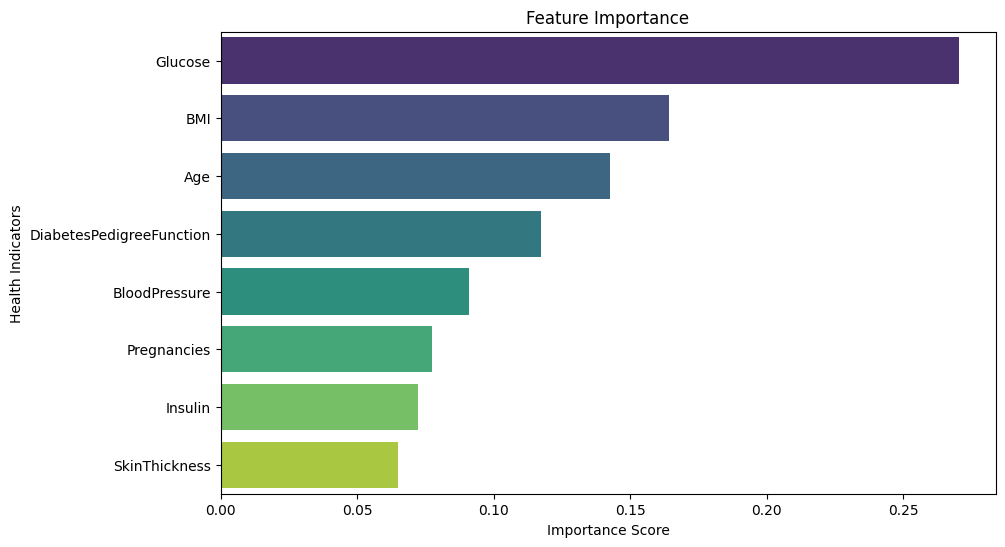

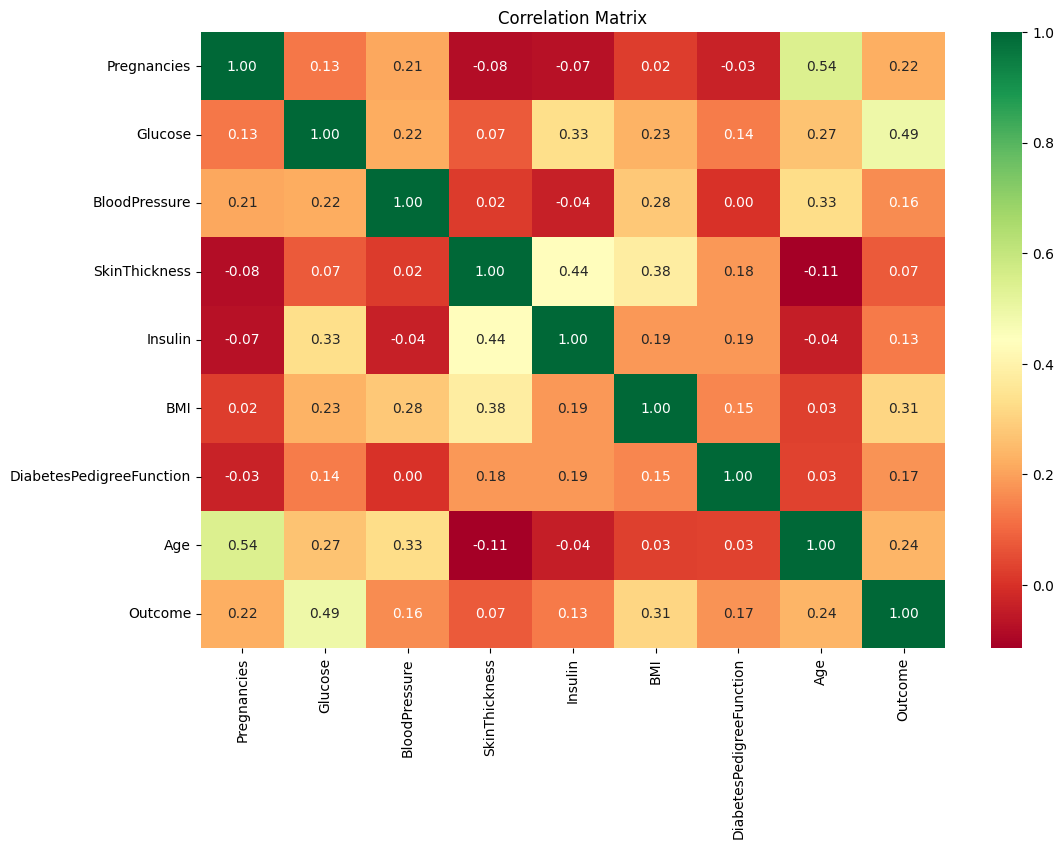

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Feature Importance Plot
features = X.columns
importances = model.feature_importances_
data_plot = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=data_plot, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Health Indicators')
plt.show()

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 🔗 Project References
- https://github.com/Priyanshu88/Diabetes-Prediction  
- https://github.com/nicolelumagui/ML-Exercise_Pima-Indians-Diabetes_Classification  
- https://github.com/anandprakash0/Diabetes-prediction  
- https://github.com/omkarkshet/Diabetes-Prediction-Using-Machine-Learning-Techniques